In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import numpy as np

In [3]:
df = pd.read_csv('PlayTennis 1.csv')
df.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [4]:
from sklearn.preprocessing import OrdinalEncoder
outlook_encoder = OrdinalEncoder()
df['Outlook'] = outlook_encoder.fit_transform(df[['Outlook']])

temp_encoder = OrdinalEncoder()
df['Temperature'] = temp_encoder.fit_transform(df[['Temperature']])

hm_encoder = OrdinalEncoder()
df['Humidity'] = hm_encoder.fit_transform(df[['Humidity']])

w_encoder = OrdinalEncoder()
df['Wind'] = w_encoder.fit_transform(df[['Wind']])

play_encoder = OrdinalEncoder()
df['Play Tennis'] = play_encoder.fit_transform(df[['Play Tennis']])
df

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0
5,1.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,1.0
7,2.0,2.0,0.0,1.0,0.0
8,2.0,0.0,1.0,1.0,1.0
9,1.0,2.0,1.0,1.0,1.0


In [5]:
x = df.drop(['Play Tennis'],axis=1)
y = df['Play Tennis']


In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

In [9]:
clf1 = DecisionTreeClassifier(criterion='entropy')
clf1.fit(x_train,y_train)
y_pred1 = clf1.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(f"accuracy with gini: ",accuracy_score(y_test,y_pred))
print(f"classification report with gini: ",classification_report(y_test,y_pred))
print(f"confusion_matrix with gini: ",confusion_matrix(y_test,y_pred))

accuracy with gini:  0.6666666666666666
classification report with gini:                precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

confusion_matrix with gini:  [[0 1]
 [0 2]]


c:\Users\tasne\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tasne\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tasne\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [11]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(f"accuracy with entropy: ",accuracy_score(y_test,y_pred1))
print(f"classification report with entropy: ",classification_report(y_test,y_pred1))
print(f"confusion_matrix with entropy: ",confusion_matrix(y_test,y_pred1))

accuracy with entropy:  1.0
classification report with entropy:                precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

confusion_matrix with entropy:  [[1 0]
 [0 2]]


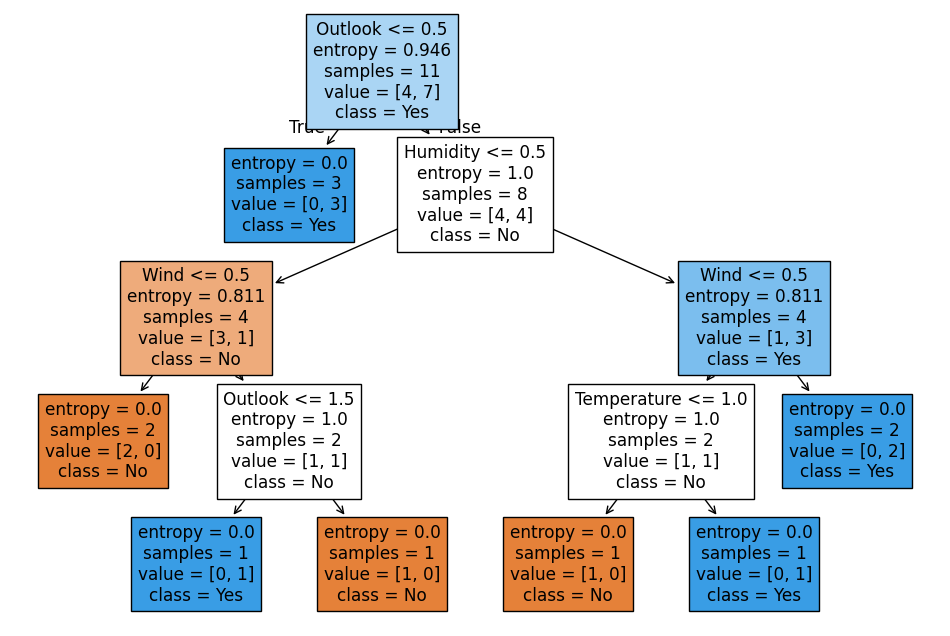

In [12]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf1,filled=True,feature_names=x.columns,class_names=play_encoder.categories_[0])
plt.show()
